# 전통적 방식과 머신러닝 방식

## 전통적 방식

In [3]:
# ****** 참조) https://wikidocs.net/223697

# 전통적 방식 : 누군가 규칙과 기준을 정해준다. (프로그래머 본인, 기획자, 팀 회의, 고객사 등)

# 길이가 30cm 이상, 무게 150kg 이상은 도미
fish_length=int(input("생선의 길이 입력하세요:"))   
fish_weight=int(input("생선의 무게 입력하세요:"))   

if fish_length >=30 and fish_weight >= 150:
    print("도미")

생선의 길이 입력하세요: 20
생선의 무게 입력하세요: 100


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns     

import matplotlib.pyplot as plt   
import matplotlib as mpl          
mpl.rc('font', family='Malgun Gothic')    
plt.rcParams['axes.unicode_minus']=False

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from scipy import stats

from sklearn.datasets import load_iris
from sklearn.metrics import classification_report

## 머신러닝 방식
### 데이터 수집 및 정제
- 목적 : 도미 (Bream, 브림) VS 빙어(Smelt, 스멜트)  
- 데이터 (관측치) : N=49
- 특성 (속성, feature) : 길이 (Length, 렝스)와 무게 (Weight, 웨이트)  
- 알고리즘 선택 : 이중 분류 (binary classfication)

In [11]:
fish_data=pd.read_csv('./Data/mulgogi_data.csv')
fish_data.shape         # (49, 3)
fish_data.head(3)       # 생물학적 분류 (스피시스)

,Species,Length,Weight
0,Bream,25.4,242.0
1,Bream,26.3,290.0
2,Bream,26.5,340.0


In [13]:
fish_data.info()                          # 데이터 구조 및 타입 및 결측치 Check

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  49 non-null     str    
 1   Length   49 non-null     float64
 2   Weight   49 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.5 KB


In [15]:
fish_data.describe().T.round(2)           # 연속형 데이터 - 기술 통계량 및  이상치 Check

,count,mean,std,min,25%,50%,75%,max
Length,49.0,27.06,10.24,9.8,14.3,31.0,34.5,41.0
Weight,49.0,444.50,328.14,6.7,19.7,500.0,700.0,1000.0


In [17]:
fish_data.describe(include='str').T  

,count,unique,top,freq
Species,49,2,Bream,35


In [19]:
fish_data['Species'].value_counts()      # 범주형 데이터 - 통계량 (빈도수 확인)

Species
Bream    35
Smelt    14
Name: count, dtype: int64

In [21]:
fish_data.corr(numeric_only=True).round(2)   # 상관분석

,Length,Weight
Length,1.00,0.96
Weight,0.96,1.00


### 시각화
- 단일 변수
    - 연속형 (숫자형) 시각화 : histplot
    - 범주형 (문자형) 시각화 : countplot, pie

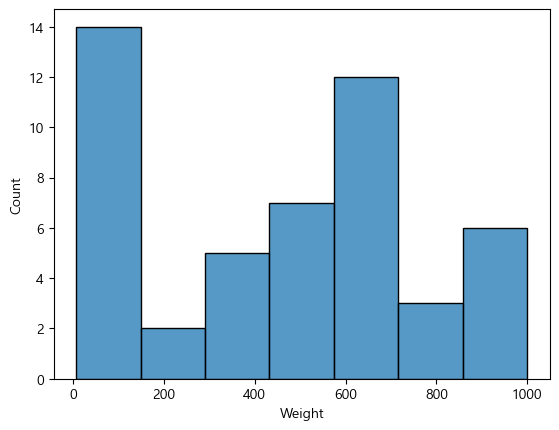

In [61]:
# 연속형 (숫자형
sns.histplot(data=fish_data, x='Weight')
plt.show()

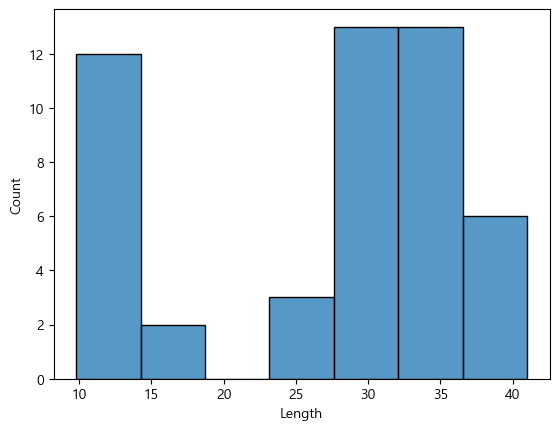

In [63]:
sns.histplot(data=fish_data, x='Length')
plt.show()

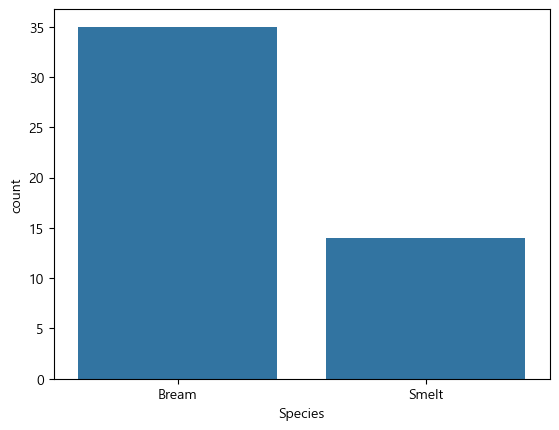

In [68]:
# 범주형 (문자형)
sns.countplot(data=fish_data, x='Species')      
plt.show()

* 다변수 (숫자, 숫자)
    * Scatter Char(산점도), 회귀선, 두 집단의 상관성 (상관관계, 히트맵)

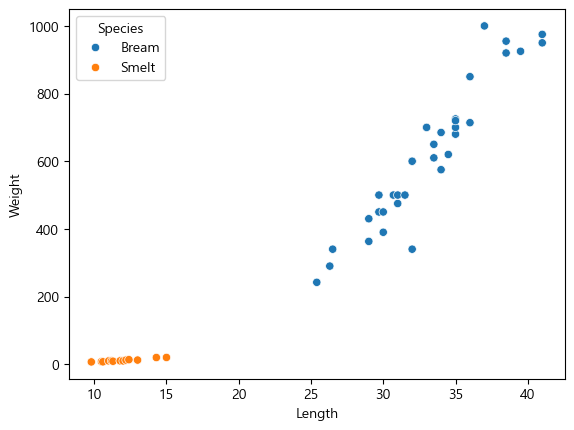

In [75]:
# 산점도
sns.scatterplot(data=fish_data, x='Length', y='Weight', hue='Species')     
# sns.lmplot(data=fish_data, x='Length', y='Weight', hue='Species')     # 회귀선
plt.show()

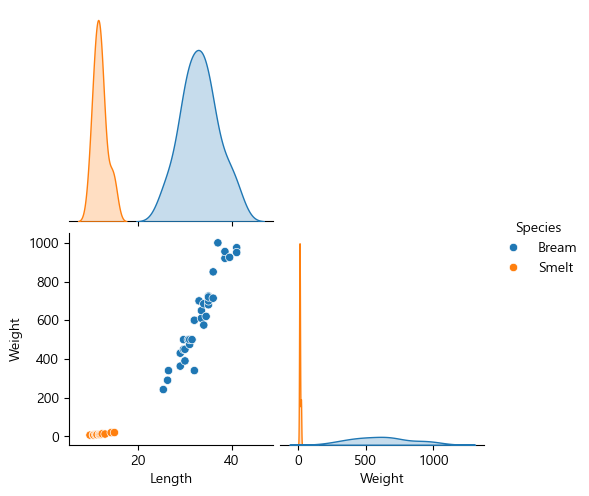

In [58]:
# 연속형 >> 히스토그램, 산점도 시각화
sns.pairplot(data=fish_data, corner=True, hue='Species')   
plt.show()

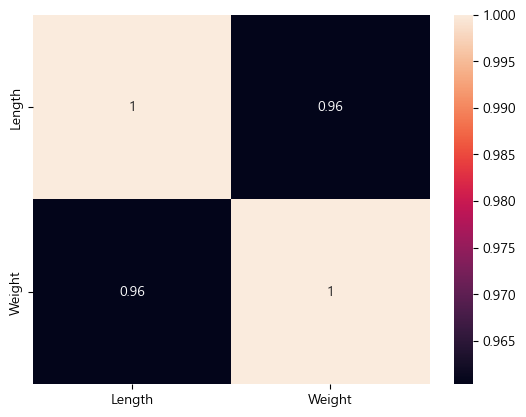

In [110]:
# 상관분석 시각화
sns.heatmap(fish_data.corr(numeric_only=True), annot=True)
plt.show()

### 모델 학습 및 평가 

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

#### K-Nearest Neighbors 
- 니어러스트 네이버즈 / 네이버즈 클래서파여
- KNeighborsClassifier() 
    - n_neighbors=5 : 이웃의 개수를 지정
    - weights='uniform' : 이웃점의 가중치 방식 {'uniform', 'distance'} or callable
    - algorithm='auto' : 거리 탐색 알고리즘{'auto', 'ball_tree', 'kd_tree', 'brute'}
    - leaf_siz=30 : 트리 분기 크기 int
    - p=2 : 거리를 재는 방법, 맨해튼 거리(1), 유클리디안 거리(2)
    - metric='minkowski' : 거리 계산 방식 str or callable
    - n_jobs : CPU 코어 지정, -1로 설정하면 모든 CPU 코어를 사용
    - 파라미터 조절은 추후 GridSerach RandomSearch
- 공통적으로 사용되는 함수들
    - fit() : 모델을 훈련할 때 사용하는 메서드, 훈련에 사용할 특성과 정답 데이터 전달
    - score() : 훈련된 모델의 성능 측정할 때 사용하는 메서드
    - predict() : 모델을 훈련하고 예측할 때 사용하는 메서드

In [25]:
# 훈련 데이터(trainging data) 
X=fish_data[['Length', 'Weight']]          # 설명변수 / input (입력 데이터)
Y=fish_data['Species']                     # 목표변수 / target (정답 데이터)
X.shape, Y.shape, type(X), type(Y)

((49, 2), (49,), pandas.DataFrame, pandas.Series)

In [27]:
# K-최근접 이웃 알고리즘 - 네이버즈 클래서파여
knn=KNeighborsClassifier(n_neighbors=5)     # 객체(최근접이웃=5) 기본값 5 생략 가능

# 학습 또는 훈련
knn.fit(X, Y)                               # 입력 데이터, 정답 데이터

# 정확도
knn.score(X, Y)                             # (정확히 맞힌 개수 / 전체 데이터 개수) 100%

1.0

In [29]:
# 예측 : 길이 30cm, 무게 600g, 
new_df=pd.DataFrame(data=[[30, 500]], columns=['Length', 'Weight'])
new_df  

,Length,Weight
0,30,500


In [31]:
knn.predict(new_df)                       # 주변에 5개를 비교해서 예측한다.

array(['Bream'], dtype=object)

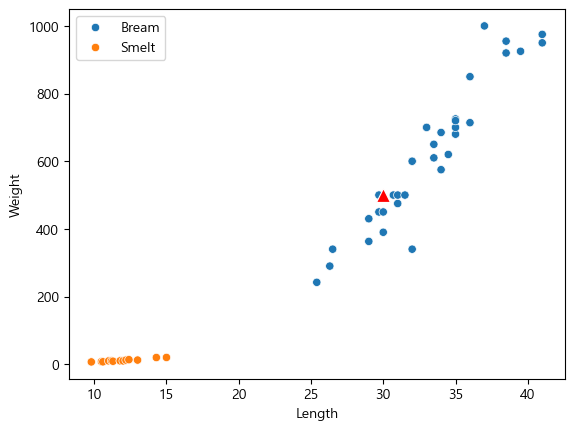

In [33]:
sns.scatterplot(data=fish_data, x='Length', y='Weight', hue='Species')
sns.scatterplot(data=new_df, x='Length', y='Weight', marker='^', color='red', s=100)  # s는 **kwargs >> 맷에서 가져옴
plt.show()

In [35]:
d, i=knn.kneighbors(new_df)
print(d)             # 가장 가까운 이웃과의 거리 계산 값
print(i)             # 가장 가까운 이웃의 인덱스

[[ 0.3         0.7         1.          1.5        25.01999201]]
[[ 6  9 11 12 10]]


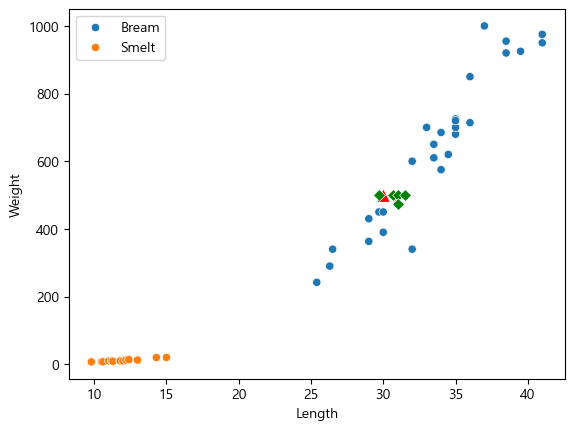

In [37]:
sns.scatterplot(data=fish_data, x='Length', y='Weight', hue='Species')
sns.scatterplot(data=new_df, x='Length', y='Weight', marker='^', color='red', s=100)

for idx in i:      # 가장 가까운 이웃의 인덱스
    sns.scatterplot(data=fish_data, 
                    x=fish_data.loc[idx, 'Length'], 
                    y=fish_data.loc[idx, 'Weight'], 
                    marker='D', 
                    color='green')

plt.show()

#### 데이터 분할 - 훈련 셋과 테스트 셋 
* stratify(스트래터파이)
  - stratify=Y 타깃 클래스 비율을 그대로 유지한 채로 데이터 분할
  - 훈련 데이터가 작거나, 특정 클래스의 샘플이 적을 때
* random_state=42 : 결과를 동일하게 유지
* shuffle=True : 무작위로 섞는다.
* test_size : 기본 값(default) 0.25

In [40]:
# 훈련 세트, 테스트 세트 :  기본값 0.25
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1234)  
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((39, 2), (10, 2), (39,), (10,))

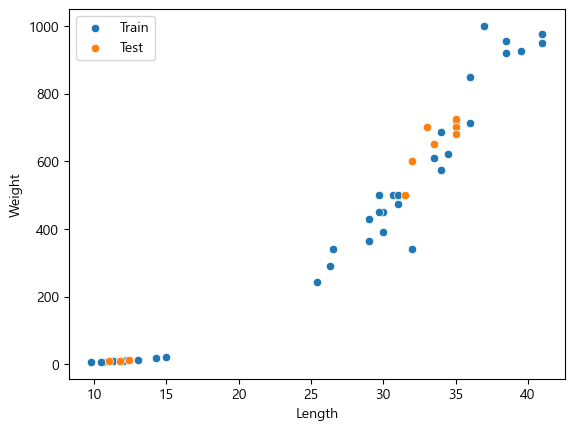

In [42]:
sns.scatterplot(data=X_train, x='Length', y='Weight', label='Train')
sns.scatterplot(data=X_test, x='Length', y='Weight', label='Test')
plt.show()

In [44]:
# 모델(알고리즘) - 분류
knn=KNeighborsClassifier()

# 학습
knn.fit(X_train, Y_train)

# 정확도
print("학습 능력:", knn.score(X_train, Y_train))   
print("일반화 능력:", knn.score(X_test, Y_test))      

학습 능력: 1.0
일반화 능력: 1.0


In [46]:
# 예측 데이터프레임 넣고 비교
Y_test_pred=knn.predict(X_test)

result=X_test.copy()
result["정답"]=Y_test
result["예측"]=Y_test_pred
result.head()

,Length,Weight,정답,예측
38,11.0,9.7,Smelt,Smelt
24,35.0,700.0,Bream,Bream
25,35.0,725.0,Bream,Bream
12,31.5,500.0,Bream,Bream
19,33.5,650.0,Bream,Bream


In [57]:
# 예측
a=pd.DataFrame(data=[[30, 500]], columns=['Length', 'Weight'])
knn.predict(a)

array(['Bream'], dtype=object)

In [59]:
# 예측 제대로 했는가? 데이터의 스케일이 다르면  정확한 값을 예측 할 수 없다.
b=pd.DataFrame(data=[[25, 150]], columns=['Length', 'Weight'])
knn.predict(b)      

array(['Smelt'], dtype=object)

In [62]:
fish_data.groupby('Species')[['Length', 'Weight']].agg([max, min])

Length        Weight       
           max   min     max    min
Species                            
Bream     41.0  25.4  1000.0  242.0
Smelt     15.0   9.8    19.9    6.7

#### 데이터 변환( Scalling ) - 연속형
* Scalling : 연속형 데이터 Scale 맞추는 작업 <br>
  - Standard Scaler (표준화, Z-score): 정규 분포일때, 데이터가 대략 대칭적이고 이상치가 많지 않을 때
     - 모든 숫자 데이터를 평균 0 / 표준편차 1
  - Min Max Scaler (Normalization, 정규화): 비선형 모델, 신경망 등
      - 모든 숫자 데이터를 최소값 0 / 최대값 1
  - Robust Scaler : 이상치가 많을때   로버스트 
       - 모슨 숫자 데이터를 중앙값 0 /  IQR 1 

In [86]:
# 표준화란 기준을 맞추는것 : 두 특성(길이와 무게)의 값이 놓인 범위가 매우 다르다. (Scale 다르다)

# 훈련 세트, 테스트 세트
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1234)

# 표준화 작업
scaler=StandardScaler()    # 표준화 객체 제공
scaler.fit(X_train)        # 평균과 표준편차 : Z-Score(표준점수)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

# 모델(알고리즘) - 분류
knn=KNeighborsClassifier()

# 학습
knn.fit(X_train_scaled, Y_train)

# 정확도
knn.score(X_train_scaled, Y_train)
knn.score(X_test_scaled, Y_test)

1.0

In [88]:
new_df=pd.DataFrame(data=[[25, 150]], columns=['Length', 'Weight'])

new_df_scaled=scaler.transform(new_df)
knn.predict(new_df_scaled)               # 도미(Bream)  

array(['Bream'], dtype=object)

In [90]:
data={'계약기간': [12, 24, 36, 48, 60],
      '비용': [10000000, 25000000, 50000000, 75000000, 100000000],
      '연령': [20, 30, 40, 50, 80]}

df=pd.DataFrame(data=data)
df

# Standard Scaler  평균 0 / 표준편차 1
standard=StandardScaler()
# standard.fit(df)
# standard_scaler=standard.transform(df)

standard_scaled=standard.fit_transform(df)
standard_scaled_df=pd.DataFrame(data=standard_scaled, columns=df.columns)   # 결과확인
standard_scaled_df

,계약기간,비용,연령
0,-1.414214,-1.286384,-1.165543
1,-0.707107,-0.826961,-0.679900
2,0.000000,-0.061256,-0.194257
3,0.707107,0.704448,0.291386
4,1.414214,1.470153,1.748315


In [92]:
print(standard_scaled_df.mean().round(), "\n")
print(standard_scaled_df.std().round())

계약기간   -0.0
비용      0.0
연령      0.0
dtype: float64 

계약기간    1.0
비용      1.0
연령      1.0
dtype: float64


In [94]:
# 정규화(Min-Max Scaler)  0 ~ 1 사이의 수
min_max=MinMaxScaler()
min_max_scaled=min_max.fit_transform(df)

min_max_scaled_df=pd.DataFrame(data=min_max_scaled, columns=df.columns)   
min_max_scaled_df

,계약기간,비용,연령
0,0.00,0.000000,0.000000
1,0.25,0.166667,0.166667
2,0.50,0.444444,0.333333
3,0.75,0.722222,0.500000
4,1.00,1.000000,1.000000


In [96]:
print(min_max_scaled_df.max(), "\n")
print(min_max_scaled_df.min())

계약기간    1.0
비용      1.0
연령      1.0
dtype: float64 

계약기간    0.0
비용      0.0
연령      0.0
dtype: float64


In [98]:
# Robust Scaler  이상치가 많을 때 1 ~ -1 
# 중앙값(50%) 0, Q3(75%) 근처 1, Q1(25%) 근처 -1 
robust=RobustScaler()
robust_scaled=robust.fit_transform(df)  # 예시 데이터에 이상치가 없다. 

robust_scaled_df=pd.DataFrame(data=robust_scaled, columns=df.columns)     
robust_scaled_df

,계약기간,비용,연령
0,-1.0,-0.8,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,2.0


In [100]:
print(robust_scaled_df.median(), "\n")
print(robust_scaled_df.quantile(0.25), "\n")
print(robust_scaled_df.quantile(0.75))  

# 이상치가 많으면 Q3(75%) 1, Q1(25%) -1  값이 나오는데
# 현재 데이터는 이상치가 없으므로 0.5, -0.5가 출력됨!!

계약기간    0.0
비용      0.0
연령      0.0
dtype: float64 

계약기간   -0.5
비용     -0.5
연령     -0.5
Name: 0.25, dtype: float64 

계약기간    0.5
비용      0.5
연령      0.5
Name: 0.75, dtype: float64


#### 데이터 변환( OneHotEncoder ) - 범주형
* Encoding : 범주형 데이터를 연속형 숫자 데이터로 변환
  - Label Encoding : 범주형 데이터와 각 항목을 점수로 변환, 순서가 생기면 컴퓨터는 0 < 1 < 2 영향력이 더 크다고 인식
  - One Hot Encoding : 범주형 데이터를 이진 벡터로 변환 [0 0 1] 
* 참고) 목표변수는 fit메소드에서 자동으로 바뀜, 설명변수는 반드시 해줘야함

In [68]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

data={
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Gender': ['female', 'male', 'male', 'male'],
    'City': ['New York', 'Los Angeles', 'New York', 'Chicago']
}

person=pd.DataFrame(data=data)
person

,Name,Gender,City
0,Alice,female,New York
1,Bob,male,Los Angeles
2,Charlie,male,New York
3,David,male,Chicago


In [71]:
person['Gender'].value_counts()

Gender
male      3
female    1
Name: count, dtype: int64

In [81]:
# 문자를 숫자로
label=LabelEncoder()
person['Gender_label']=label.fit_transform(person['Gender'])
person

,Name,Gender,City,Gender_label
0,Alice,female,New York,0
1,Bob,male,Los Angeles,1
2,Charlie,male,New York,1
3,David,male,Chicago,1


In [83]:
# 또는
# person.insert(loc=person.columns.get_loc('Gender') + 1,
              # column='Gender_label',
              # value=label.fit_transform(person['Gender']))

In [85]:
person['City'].value_counts()

City
New York       2
Los Angeles    1
Chicago        1
Name: count, dtype: int64

In [87]:
# 문자를 숫자로
city_label=label.fit_transform(person['City'])   # 순서를 가지고 있으면 안된다.
city_label

city_label=city_label.reshape(-1, 1)            # 2차원으로 변형
city_label

# 원핫인코딩
onehot=OneHotEncoder()
city_onehot=onehot.fit_transform(city_label).toarray().astype(int)     # 배열, 정수형
city_onehot

array([[0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0]])

In [93]:
colname=onehot.get_feature_names_out(['City'])     # 컬럼명 생성['City_0', 'City_1', 'City_2']
colname

# 원핫인코딩 결과를 DataFrame으로 변환
city_onehot_df=pd.DataFrame(data=city_onehot, columns=colname)
city_onehot_df

# 원본 DataFrame과 원핫인코딩 결과 결합
concat_df=pd.concat([person, city_onehot_df], axis=1)
concat_df

,Name,Gender,City,Gender_label,City_0,City_1,City_2
0,Alice,female,New York,0,0,0,1
1,Bob,male,Los Angeles,1,0,1,0
2,Charlie,male,New York,1,0,0,1
3,David,male,Chicago,1,1,0,0


In [95]:
# 간편하게 판다스
person=pd.get_dummies(data=person, columns=['City'], dtype=int, drop_first=True)   # 다중공선상 (독립성, 질문을 하나 줄여서 뻔한 중복을 없애줌)
person                                                                             # City_Chicago (0, 0)

,Name,Gender,Gender_label,City_Los Angeles,City_New York
0,Alice,female,0,0,1
1,Bob,male,1,1,0
2,Charlie,male,1,0,1
3,David,male,1,0,0


# 실습문제 - 염색 불량 예측
- 염색 불량 예측
- 특성(feature) : 공정, 설비, 품질
- 정답(target) : 염색색차 DE / 불량여부
- N : 32608

## 학습 데이터 추출

In [8]:
data=pd.read_csv('./Data/염색공정전체데이터.csv', encoding='cp949')
data.shape

(32608, 18)

In [10]:
data['불량여부']=(data['염색색차 DE'] > 3.0).astype(int)

In [12]:
# data['불량여부'].value_counts()
data['불량여부'].value_counts(normalize=True)

불량여부
0    0.848105
1    0.151895
Name: proportion, dtype: float64

In [14]:
dye_5000, _=train_test_split(data, train_size=5000, stratify=data['불량여부'], random_state=1234)
dye_5000.shape

(5000, 19)

In [16]:
dye_5000['불량여부'].value_counts(normalize=True)

불량여부
0    0.8482
1    0.1518
Name: proportion, dtype: float64

In [18]:
dye_5000.to_csv('./Data/염색공정_5000.csv', encoding='cp949', index=False)

## 데이터 전처리

In [21]:
new_data=pd.read_csv('./Data/염색공정_5000.csv', encoding='cp949')
new_data.shape

(5000, 19)

In [23]:
new_data.columns

Index(['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '단위중량(kg)', '투입중량(kg)',
       '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)', '지시온도', '진행온도', '포속1',
       '포속2', '포속3', '포속4', '염색색차 DE', '불량여부'],
      dtype='str')

In [29]:
drop_cols=['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '염색색차 DE']
dye=new_data.drop(columns=drop_cols)

In [31]:
dye.head(2)

,단위중량(kg),투입중량(kg),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),지시온도,진행온도,포속1,포속2,포속3,포속4,불량여부
0,324.0,38.8,96.0,0.404167,0.0388,23.41,133.1,133.2,74,73,72,20,0
1,324.0,38.8,96.0,0.404167,0.0388,21.88,126.3,127.1,73,68,146,18,0


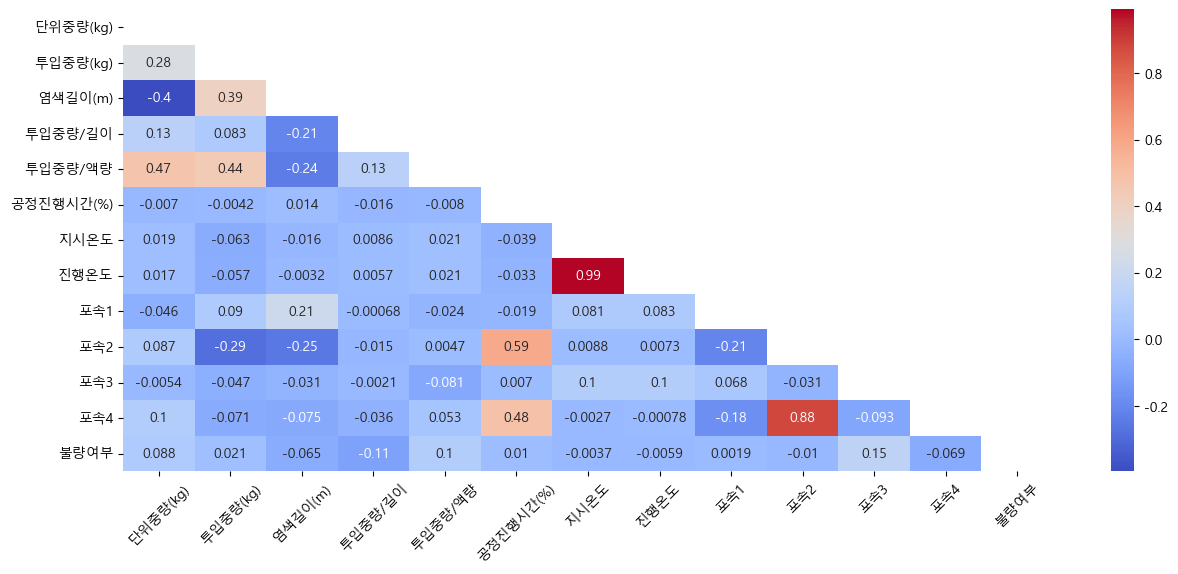

In [33]:
# 상관분석
plt.figure(figsize=(15, 6))
sns.heatmap(dye.corr(), 
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(dye.corr(), dtype=bool)))
plt.xticks(rotation=45)
plt.show()

# 다중공산성 : 0.8이상인 변수쌍 중 하나씩만 선택
# 선택 기준 : 도메인 지식 또는 상관성이 더 높은것
#             불량여부/지시온도(0.0037), 불량여부/진행온도(0.0059)   
#             불량여부/포속2(0.01), 불량여부/포속4(0.07)  

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

col=dye[['진행온도', '지시온도', '포속2', '포속4']]

vif=pd.DataFrame()
vif['변수명']=col.columns
vif["다중 공선상(VIF)"]=[variance_inflation_factor(col.values, i) for i in range(4)]
vif

# VIF < 5 → 문제 없음 (실무 기준)
# VIF ≥ 5 → 좀 높다
# VIF ≥ 10 → 심각한 다중공선성

,변수명,다중 공선상(VIF)
0,진행온도,474.691135
1,지시온도,475.615154
2,포속2,8.384958
3,포속4,7.181979


In [37]:
drop_cols=['지시온도', '포속2']
dye=dye.drop(columns=drop_cols)

In [39]:
dye.columns

Index(['단위중량(kg)', '투입중량(kg)', '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)',
       '진행온도', '포속1', '포속3', '포속4', '불량여부'],
      dtype='str')

In [41]:
dye.to_csv('./Data/염색공정_5000_분류.csv', encoding='cp949', index=False)

## 시각화

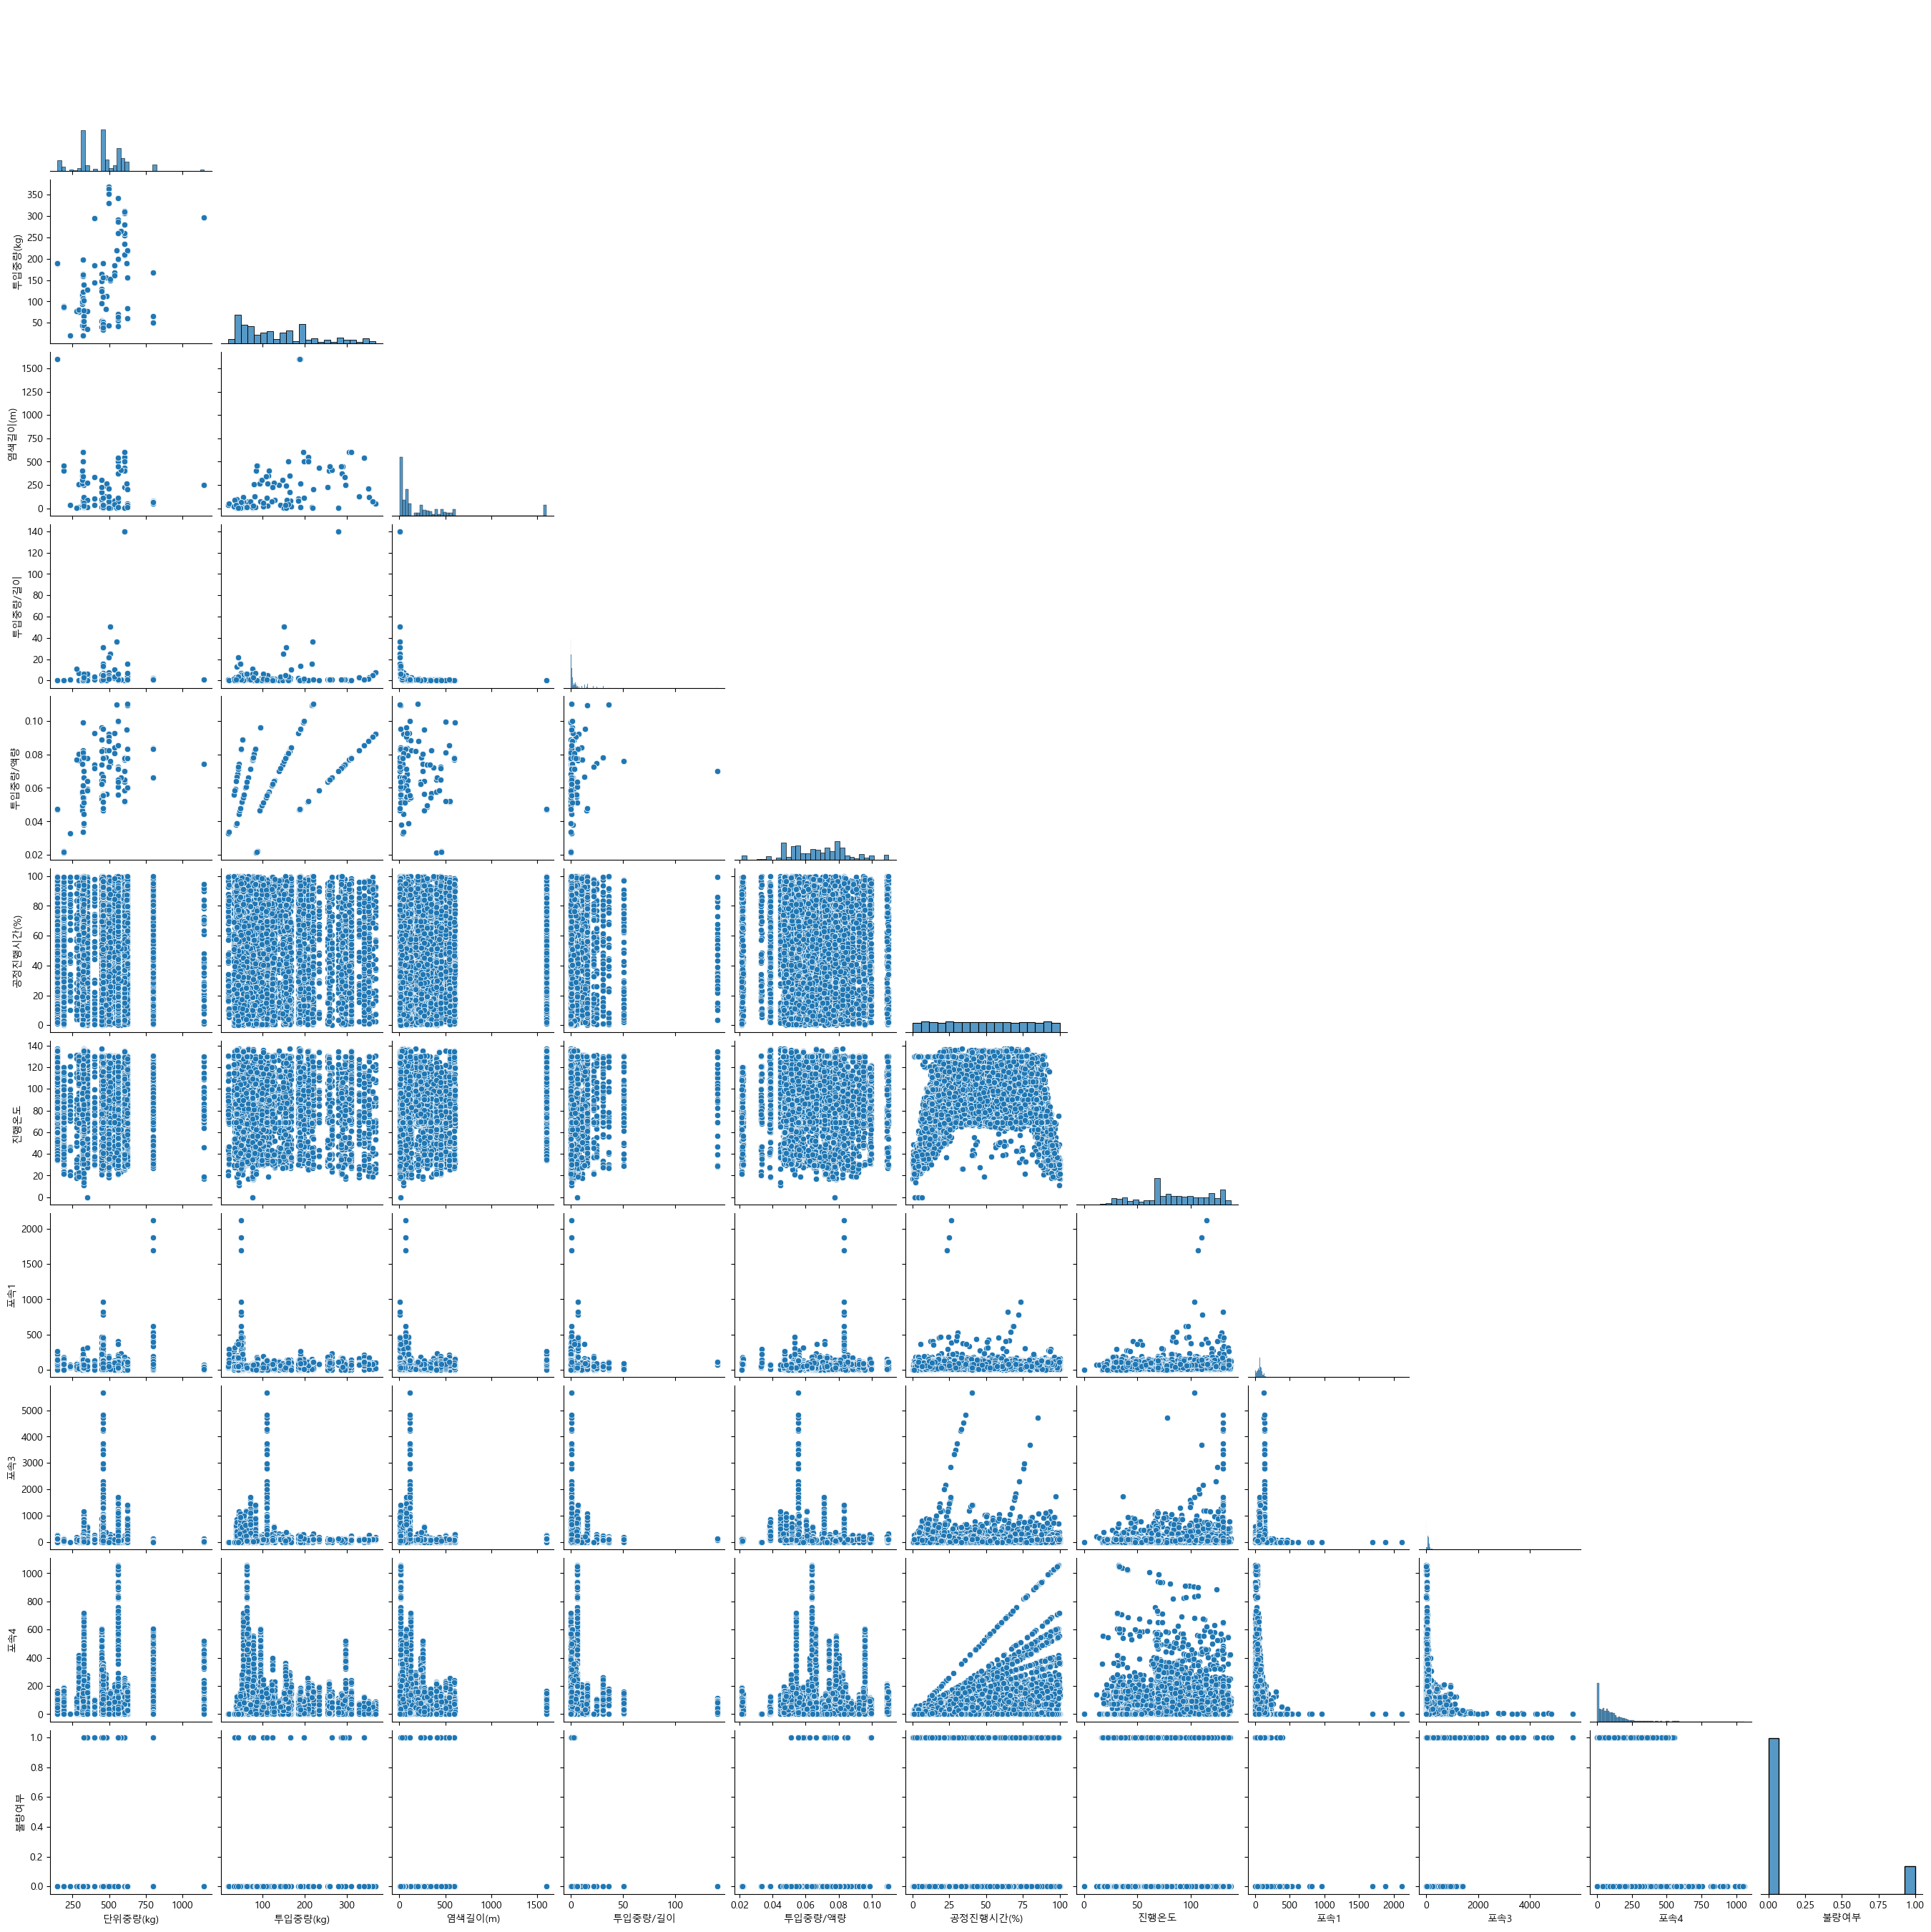

In [44]:
# 연속형 전체 데이터
sns.pairplot(data=dye, corner=True)
plt.show()

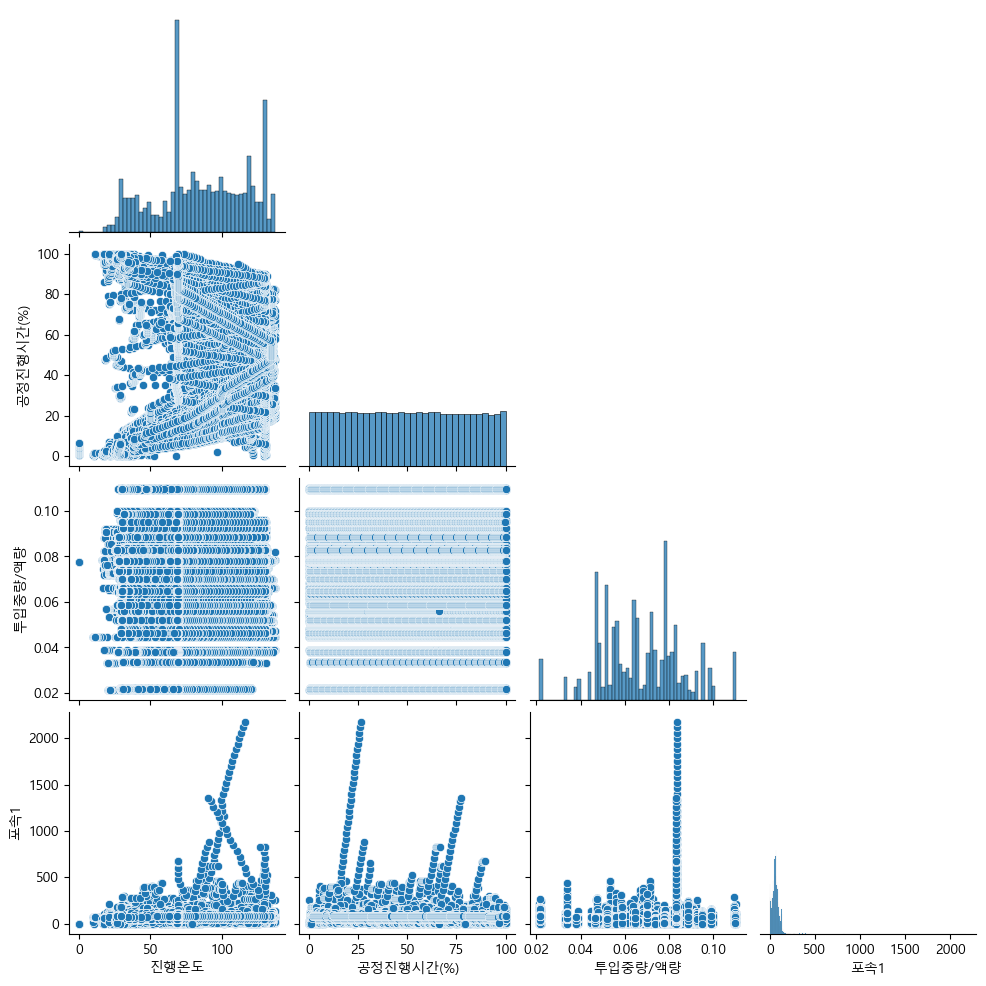

In [139]:
# 연속형 선택 변수 시각화
cols=['진행온도', '공정진행시간(%)', '투입중량/액량', '포속1']
sns.pairplot(data=dye[cols], corner=True)
plt.show()

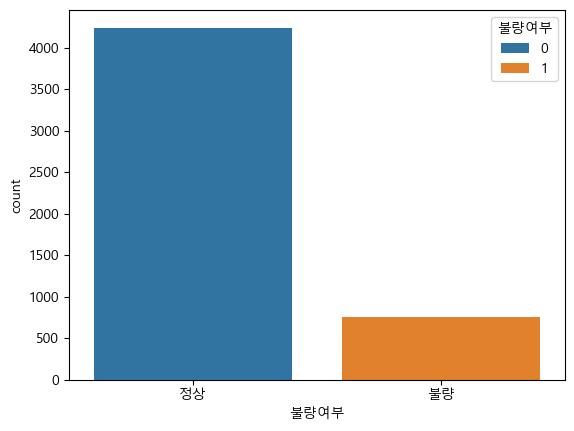

In [46]:
sns.countplot(data=dye, x='불량여부', hue='불량여부')
plt.xticks([0, 1], ['정상', '불량'])
plt.show()

## 모델 학습 및 평가지표
### 데이터 분할 및 변환

In [49]:
# 설명변수(X), 목표변수(Y)
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [51]:
# 학습 데이터, 테스트 데이터 
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, stratify=Y, random_state=1234)

In [53]:
# 표준화 
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

### 모델 학습

In [82]:
# 학습
knn=KNeighborsClassifier(n_neighbors=5)  
knn.fit(X_train_scaled, Y_train)

# 평가 
print("학습:", knn.score(X_train_scaled, Y_train))     # 학습 성능  
print("일반화:", knn.score(X_test_scaled, Y_test))     # 일반 성능

학습: 0.9696
일반화: 0.932


### 평가방법 (Evaluation)
- 오차행렬 (Confusion matrix, , 컨퓨전 메이트릭스)
  - 정확도 (Accuracy) 
  - 정밀도 (Precision) : 정상이라고 예측한것 중에 실제 정상
  - 재현율 (Recall) : 전체 데이터에서 정상으로 예측한것
  - F1 점수 (F1-Score) : 정밀도 + 재현율 조화평균

In [58]:
Y_test_pred=knn.predict(X_test_scaled)
print(classification_report(Y_test, Y_test_pred)) 

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1060
           1       0.80      0.73      0.77       190

    accuracy                           0.93      1250
   macro avg       0.88      0.85      0.86      1250
weighted avg       0.93      0.93      0.93      1250



# K-Neighbors Regressor
## 농어의 무게를 예측
* 길이로 무게 예측 / 길이
* 최근 이웃한 데이터 평균

In [151]:
from sklearn.neighbors import KNeighborsRegressor

In [281]:
# 입력 데이터 : 길이, 퍼치 렝스 
perch_length=np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
                     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
                     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
                     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
                     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
                     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])  

# 정답 데이터 : 무게, 퍼치 웨이트 
perch_weight=np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
                     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
                     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
                     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
                     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
                     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
                     1000.0, 1000.0])                   

perch_length.shape, perch_weight.shape

((56,), (56,))

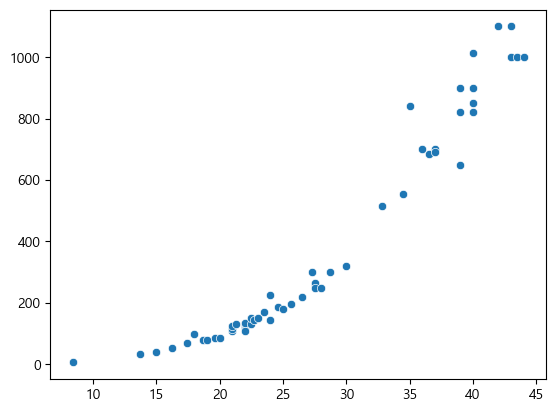

In [283]:
sns.scatterplot(x=perch_length, y=perch_weight)
plt.show()

### 훈련 & 테스트 셋 

In [286]:
X_train, X_test, Y_train, Y_test=train_test_split(perch_length, perch_weight, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape   

((42,), (14,), (42,), (14,))

### 2차원 배열 수정

In [289]:
# 1차원 >> 2차원으로 수정 
# 행의 위치에서 -1을 넣고 열의 수를 지정해주면 변환될 행은 알아서 자동으로 재배열

X_train=X_train.reshape(-1, 1)
X_test=X_test.reshape(-1, 1)
X_train.shape, X_test.shape

((42, 1), (14, 1))

### 모델 학습 및 평가

In [292]:
knr=KNeighborsRegressor(n_neighbors=3)
knr.fit(X_train, Y_train)

# 정확도
# 분류 : 100% (정확히 맞힌 개수 / 전체 데이터 개수) 
# 회귀 : 0 ~ 1  (결정계수 : R^2 = 1 - (타깃 - 예측) ^2의 합  / (타킷 - 평균) ^2의 합)
print("학습:", knr.score(X_train, Y_train))     # 정확도 계산 추후 설명
print("일반화:", knr.score(X_test, Y_test))

knr.predict([[19.6]])

학습: 0.9804899950518966
일반화: 0.9746459963987609


array([83.33333333])

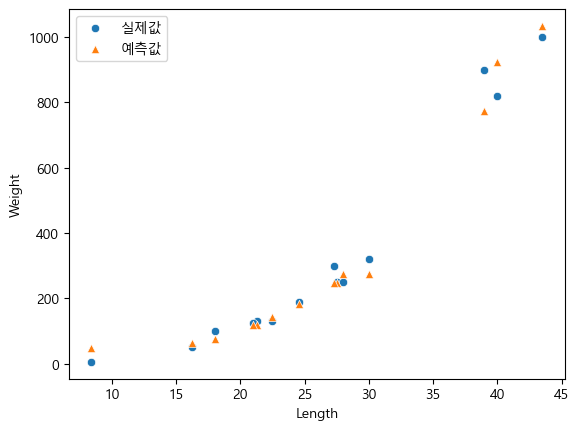

In [294]:
# 예측 시각화
Y_test_pred=knr.predict(X_test)

sns.scatterplot(x=X_test[:, 0], y=Y_test, label='실제값')
sns.scatterplot(x=X_test[:, 0], y=Y_test_pred, marker='^', label='예측값')

plt.xlabel("Length")
plt.ylabel("Weight")
plt.show()

In [296]:
# X_test
# X_test.flatten()

In [298]:
result=pd.DataFrame()

result["X_test"]=X_test.flatten()
result["Y_test"]=Y_test
result["Y_test_pred"]=Y_test_pred
result.head().round(2)

,X_test,Y_test,Y_test_pred
0,8.4,5.9,47.33
1,18.0,100.0,76.00
2,27.5,250.0,247.67
3,21.3,130.0,120.00
4,22.5,130.0,143.33


## 일반화, 과소적합, 과대적합
* 과소적합(Underfitting) : 테스트 점수가 더 높다 또는 두 점수 모두 낮다.
* 과대적합(Overfitting) / 과적합 : 훈련 데이터에는 높은 성능을 보이지만, 새로운 데이터에 대해서는 제대로 일반화하지 못하는 문제가 발생

In [301]:
knr=KNeighborsRegressor(n_neighbors=3)
knr.fit(X_train, Y_train)
print("학습:", knr.score(X_train, Y_train))
print("일반화:", knr.score(X_test, Y_test))        # 일반화 잘 되었음

학습: 0.9804899950518966
일반화: 0.9746459963987609


In [303]:
# 과소적합(Underfitting) : 테스트 점수가 더 높다 또는 두 점수 모두 낮다.
knr=KNeighborsRegressor(n_neighbors=5)
knr.fit(X_train, Y_train)
print("학습:", knr.score(X_train, Y_train))
print("일반화:", knr.score(X_test, Y_test))       

학습: 0.9698823289099254
일반화: 0.992809406101064


In [305]:
# 과소적합(Underfitting) : 테스트 점수가 더 높다 또는 두 점수 모두 낮다.
knr=KNeighborsRegressor(n_neighbors=41)   # n(Hyper Parameter)  최적 찾는 방법?
knr.fit(X_train, Y_train)
print("학습:", knr.score(X_train, Y_train))
print("일반화:", knr.score(X_test, Y_test))     

학습: 0.05978205016667115
일반화: 0.013071066272332454


In [307]:
# 과대적합(Overfitting) 또는 과적합
# 훈련 데이터에는 높은 성능을 보이지만, 새로운 데이터에 대해서는 제대로 일반화하지 못하는 문제가 발생
# 예) 훈련 데이터는 0.97 / 테스트 데이터는 0.50

In [309]:
su=perch_length.shape[0]
np.sqrt(su)       # 7.48    

7.483314773547883

In [311]:
results=[]

for i in range(3, 15, 2):
    knr=KNeighborsRegressor(n_neighbors=i)
    knr.fit(X_train, Y_train)
    train_score=knr.score(X_train, Y_train)
    test_score=knr.score(X_test, Y_test)

    results.append({
        'k': i,
        'train_score': train_score,
        'test_score': test_score
    })

In [313]:
df=pd.DataFrame(results)
df.sort_values(by=['train_score', 'test_score'], ascending=[False, False]).head()

,k,train_score,test_score
0,3,0.980490,0.974646
2,7,0.976117,0.978138
1,5,0.969882,0.992809
3,9,0.969331,0.969265
4,11,0.951576,0.970280


## K-최근접 이웃 회귀의 한계

In [316]:
knr=KNeighborsRegressor(n_neighbors=3)
knr.fit(X_train, Y_train)

print(knr.predict([[50]]))        # 학습에 없는 50cm 농어의 무게
print(knr.predict([[100]]))       # 학습에 없는 100cm 농어의 무게

[1033.33333333]
[1033.33333333]


Text(0, 0.5, 'weight')

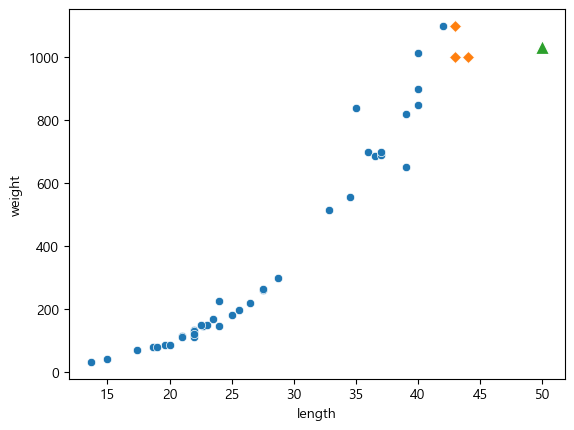

In [318]:
# 50cm 농어 이웃의 거리와 인덱스
d, i=knr.kneighbors([[50]])
d, i

# 훈련 세트의 산점도
sns.scatterplot(x=X_train[:, 0], y=Y_train)

# 50cm 농어의 이웃 산점도
for idx in i:
    sns.scatterplot(x=X_train[idx, 0], y=Y_train[idx], marker='D')

# 50cm 농어 데이터 산점도
sns.scatterplot(x=[50], y=[1033], marker='^', s=100)

plt.xlabel('length')
plt.ylabel('weight')

Text(0, 0.5, 'weight')

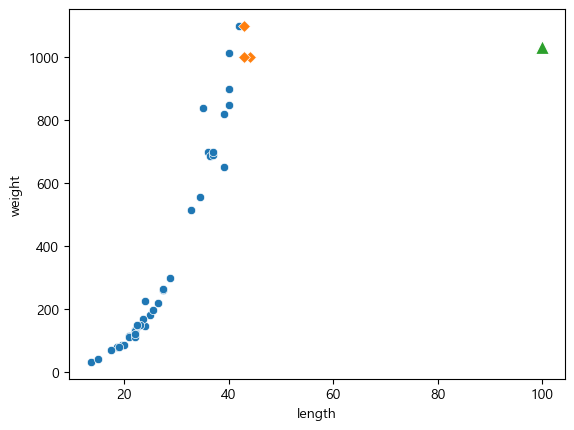

In [323]:
# 100cm 농농어 이웃의 거리와 인덱스
d, i=knr.kneighbors([[100]])
d, i

# 훈련 세트의 산점도
sns.scatterplot(x=X_train[:, 0], y=Y_train)

# 100cm 농어의 이웃 산점도
for idx in i:
    sns.scatterplot(x=X_train[idx, 0], y=Y_train[idx], marker='D')

# 100cm 농어 데이터 산점도
sns.scatterplot(x=[100], y=[1033], marker='^', s=100)
plt.xlabel('length')
plt.ylabel('weight')

# K-최근접이웃 회귀
# 비슷한 지역에 있는 주택들의 가격을 예측
# 비슷한 건강 상태를 가진 환자들의 정보를 사용하여 새로운 환자의 건강 상태를 예측
# 비슷한 제품의 판매 이력을 사용하여 재고 수요 예측 등

## 실습문제 - 품질 측정 값 예측
### 데이터 전처리

In [84]:
data=pd.read_csv('./Data/염색공정_5000.csv', encoding='cp949')
data.shape

(5000, 19)

In [86]:
data.columns

Index(['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '단위중량(kg)', '투입중량(kg)',
       '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)', '지시온도', '진행온도', '포속1',
       '포속2', '포속3', '포속4', '염색색차 DE', '불량여부'],
      dtype='str')

In [88]:
drop_cols=['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '불량여부', '지시온도', '포속2']
dye=data.drop(columns=drop_cols)

In [90]:
dye.columns

Index(['단위중량(kg)', '투입중량(kg)', '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)',
       '진행온도', '포속1', '포속3', '포속4', '염색색차 DE'],
      dtype='str')

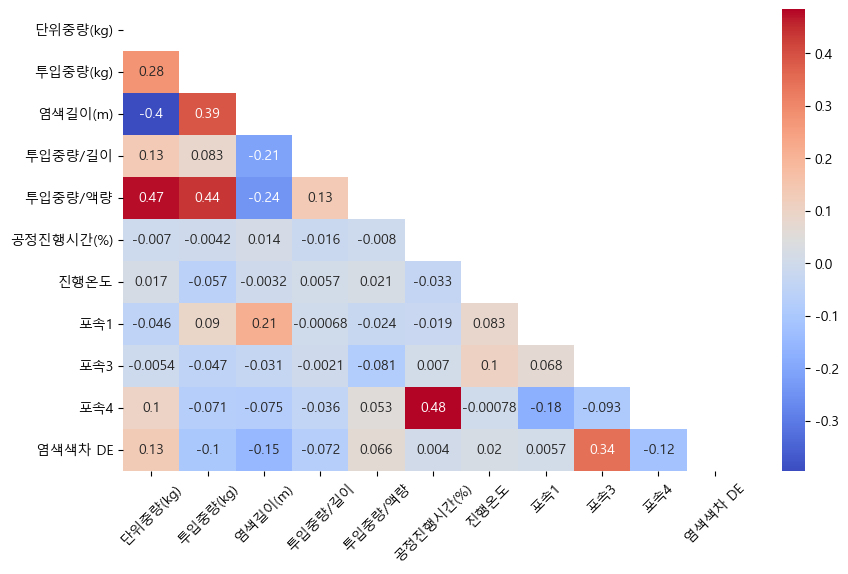

In [92]:
plt.figure(figsize=(10, 6))
sns.heatmap(dye.corr(), 
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(dye.corr(), dtype=bool)))
plt.xticks(rotation=45)
plt.show()

In [94]:
dye.to_csv('./Data/염색공정_5000_회귀.csv', encoding='cp949', index=False)

### 학습 및 평가

In [97]:
# 설명변수(X), 목표변수(Y)
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [99]:
# 학습 데이터, 테스트 데이터 
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, random_state=1234)

In [101]:
# 표준화
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [103]:
# 학습
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, Y_train)

# 평가 
print("학습:", knn.score(X_train_scaled, Y_train))     # 학습 성능  
print("일반화:", knn.score(X_test_scaled, Y_test))     # 일반 성능

학습: 0.8810962754177369
일반화: 0.7984860356299872


In [107]:
results=[]

for i in range(5, 70, 6):
    knr=KNeighborsRegressor(n_neighbors=i)
    knr.fit(X_train_scaled, Y_train)
    train_score=knr.score(X_train_scaled, Y_train)
    test_score=knr.score(X_test_scaled, Y_test)

    results.append({
        'k': i,
        'train_score': train_score,
        'test_score': test_score
    })

In [108]:
df=pd.DataFrame(results)
df.sort_values(by=['train_score', 'test_score'], ascending=[False, False]).head()

,k,train_score,test_score
0,5,0.881096,0.798486
1,11,0.749173,0.671849
2,17,0.652662,0.582962
3,23,0.571477,0.524075
4,29,0.512764,0.477855


In [109]:
# End of -------------------------------------------------------------------